#introduccion:
Se modeló la concentración de PM2.5 en Arizona (2024–2025) para evaluar patrones espacio-temporales y capacidad predictiva. Se priorizó información ambiental directa, evitando redundancias como el AQI, con el objetivo de construir un modelo robusto y generalizable a nivel estatal.
#Metodología:
Se integraron datos de múltiples condados de Arizona (2024–2025). Se eliminaron valores erróneos y se generaron variables temporales (mes, estacionalidad). Se aplicó regresión lineal con partición entrenamiento/prueba (80/20). Se excluyó AQI para evitar colinealidad directa con PM2.5.
#Resultados
El modelo alcanzó un MSE de 79.2530 y un R² de 0.8096, indicando alta capacidad explicativa. Las variables temporales y espaciales contribuyeron significativamente, capturando variabilidad estacional y diferencias regionales en concentraciones de PM2.5.

#Discusión
Excluir AQI evitó redundancia predictiva y mejoró la interpretabilidad. El uso de datos estatales permitió capturar heterogeneidad espacial, a diferencia de modelos basados en un solo condado. Sin embargo, la linealidad limita la captura de dinámicas no lineales complejas.

#Conclusiones
El modelo predice eficazmente PM2.5 en Arizona con alta precisión (R²>0.8). La inclusión de múltiples regiones y la exclusión de variables redundantes son clave. Se recomienda incorporar modelos no lineales y variables meteorológicas para mejorar el desempeño predictivo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. CARGA DE DATOS
# ==========================================

data1 = pd.read_csv('A2024_pm25.csv')  # 2024 en tu caso
data2 = pd.read_csv('A2025_pm25.csv')  # 2025 en tu caso

df = pd.concat([data1, data2], ignore_index=True)

In [ ]:
df.head(19178)

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2024,AQS,40011235,1,1.3,ug/m3 LC,7,Nazlini,1,100.0,...,117.0,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
1,01/07/2024,AQS,40011235,1,1.0,ug/m3 LC,6,Nazlini,1,100.0,...,117.0,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
2,01/13/2024,AQS,40011235,1,0.8,ug/m3 LC,4,Nazlini,1,100.0,...,117.0,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
3,01/19/2024,AQS,40011235,1,1.0,ug/m3 LC,6,Nazlini,1,100.0,...,117.0,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
4,01/25/2024,AQS,40011235,1,1.1,ug/m3 LC,6,Nazlini,1,100.0,...,117.0,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19173,12/27/2025,AQS,40278011,3,2.9,ug/m3 LC,16,YUMA SUPERSITE,1,100.0,...,638.0,Teledyne T640X at 16.67 LPM w/Network Data Ali...,49740.0,"Yuma, AZ",4,Arizona,27,Yuma,32.690278,-114.614440
19174,12/28/2025,AQS,40278011,3,1.5,ug/m3 LC,8,YUMA SUPERSITE,1,100.0,...,638.0,Teledyne T640X at 16.67 LPM w/Network Data Ali...,49740.0,"Yuma, AZ",4,Arizona,27,Yuma,32.690278,-114.614440
19175,12/29/2025,AQS,40278011,3,2.4,ug/m3 LC,13,YUMA SUPERSITE,1,100.0,...,638.0,Teledyne T640X at 16.67 LPM w/Network Data Ali...,49740.0,"Yuma, AZ",4,Arizona,27,Yuma,32.690278,-114.614440
19176,12/30/2025,AQS,40278011,3,2.3,ug/m3 LC,13,YUMA SUPERSITE,1,100.0,...,638.0,Teledyne T640X at 16.67 LPM w/Network Data Ali...,49740.0,"Yuma, AZ",4,Arizona,27,Yuma,32.690278,-114.614440


In [ ]:
df.describe()

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,1.917800e+04,19178.000000,19178.000000,19178.000000,19178.0,19178.0,19178.000000,19073.000000,18170.000000,19178.0,19178.000000,19178.000000,19178.000000
mean,4.016831e+07,2.669152,7.005704,34.497914,1.0,100.0,88212.844249,376.322288,40673.306549,4.0,16.494786,32.999638,-111.722033
std,4.942647e+04,0.720449,6.881623,19.171925,0.0,0.0,179.839079,254.760819,4907.056547,0.0,5.019875,0.866139,0.914557
min,4.001124e+07,1.000000,-2.500000,0.000000,1.0,100.0,88101.000000,117.000000,22380.000000,4.0,1.000000,31.337204,-114.614440
25%,4.013400e+07,3.000000,3.900000,22.000000,1.0,100.0,88101.000000,170.000000,38060.000000,4.0,13.000000,32.295150,-112.095767
50%,4.019001e+07,3.000000,5.800000,32.000000,1.0,100.0,88101.000000,182.000000,38060.000000,4.0,19.000000,33.403140,-111.865360
75%,4.019111e+07,3.000000,8.400000,47.000000,1.0,100.0,88502.000000,707.000000,46060.000000,4.0,19.000000,33.483780,-110.996440
max,4.027801e+07,3.000000,322.500000,494.000000,1.0,100.0,88502.000000,733.000000,49740.000000,4.0,27.000000,35.973117,-109.389060


In [ ]:
df.isnull().sum()

,0
Date,0
Source,0
Site ID,0
POC,0
Daily Mean PM2.5 Concentration,0
Units,0
Daily AQI Value,0
Local Site Name,0
Daily Obs Count,0
Percent Complete,0


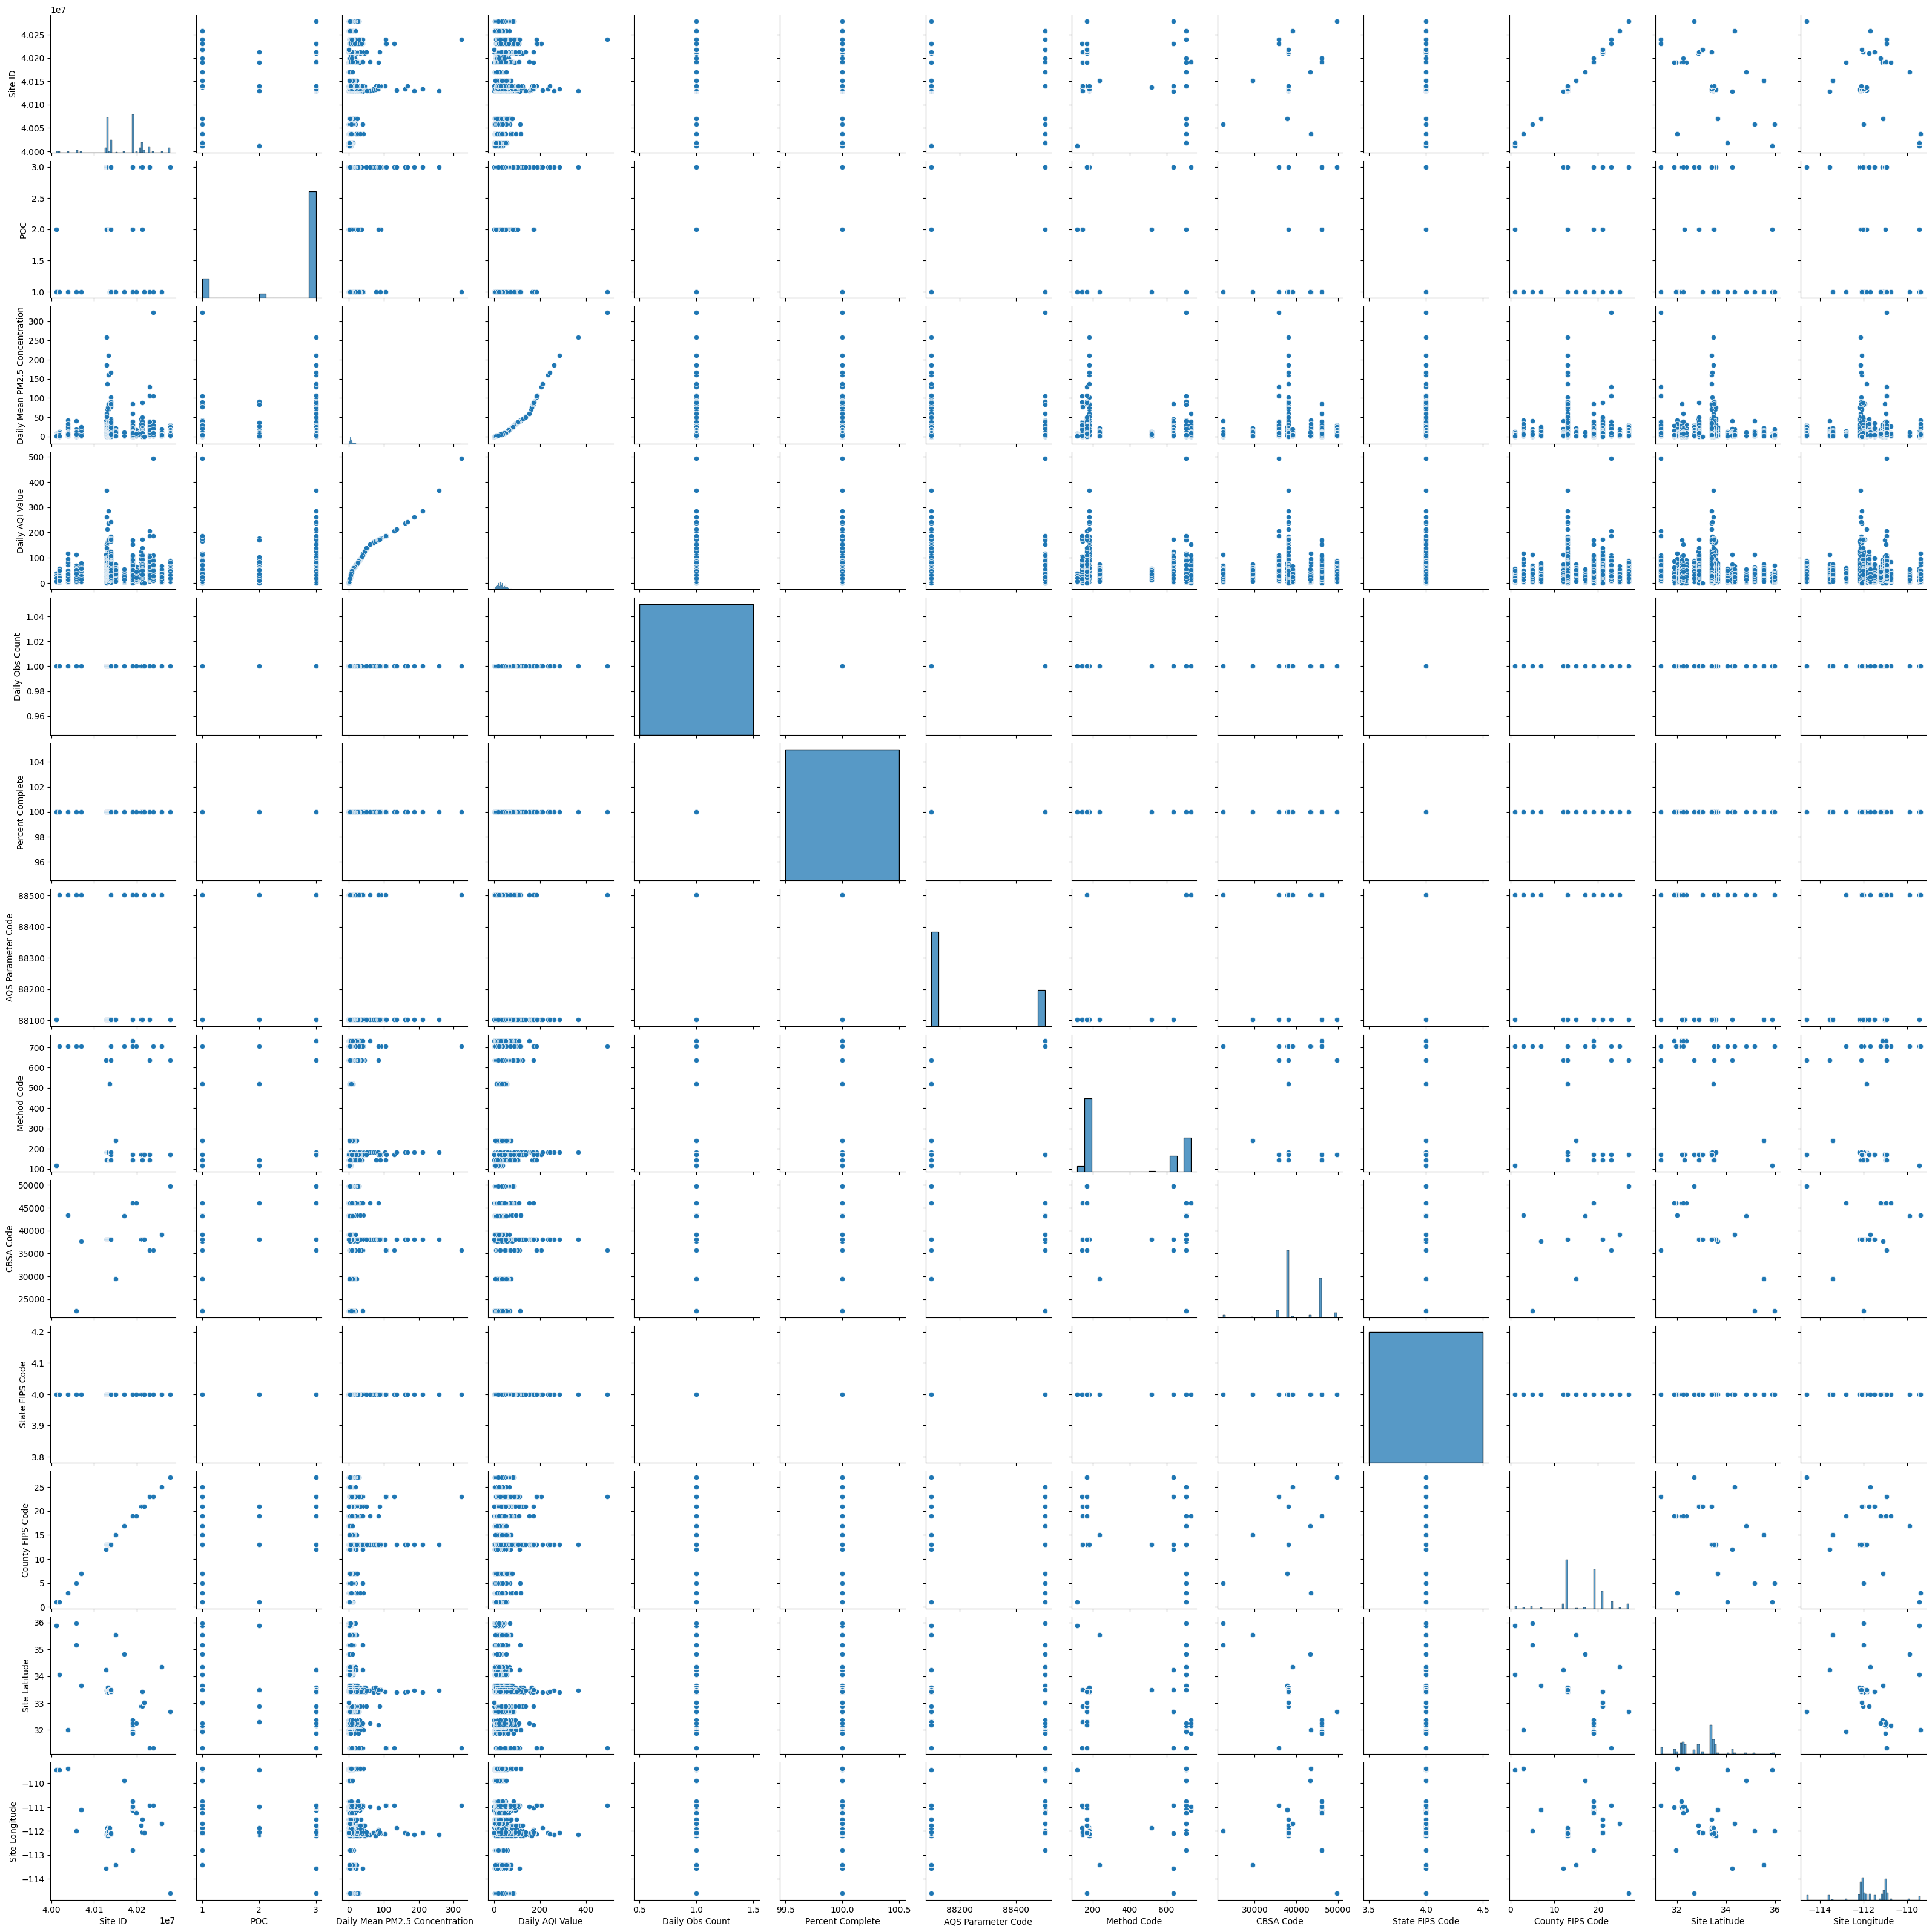

In [ ]:
sns.pairplot(df)

/tmp/ipykernel_48527/309748370.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])



--- MODELO CORREGIDO ---
MSE: 79.2530
R2: 0.8096


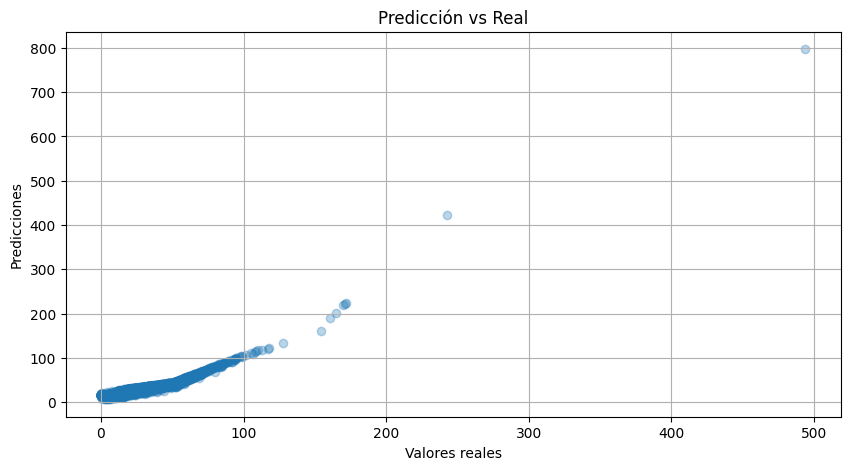


Variables más influyentes:
             Variable  Coeficiente
16        County_Yuma    49.672717
14  County_Santa Cruz    43.642569
13       County_Pinal    36.469511
15     County_Yavapai    35.621540
12        County_Pima    33.171794
9     County_Maricopa    29.180749
10      County_Mohave    28.085120
11      County_Navajo    23.951806
8       County_La Paz    21.475639
7         County_Gila    11.631055


In [ ]:


# ==========================================
# 2. LIMPIEZA DE DATOS
# ==========================================

# Convertir fecha
df['Date'] = pd.to_datetime(df['Date'])

# Eliminar valores negativos en contaminantes
df = df[df['Daily Mean PM2.5 Concentration'] >= 0]

# ==========================================
# 3. FEATURE ENGINEERING (CLAVE)
# ==========================================

# Variables temporales (MUY IMPORTANTES)
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek

# Variable cíclica (estacionalidad)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# ==========================================
# 4. SELECCIÓN DE VARIABLES (SIN LEAKAGE)
# ==========================================

# ❌ NO usar AQI como input
# ✔ usar contaminantes + tiempo + categóricas

features = [
    'Daily Mean PM2.5 Concentration',
    'month_sin',
    'month_cos',
    'day_of_week'
]

# Variables categóricas útiles
categorical_cols = ['State', 'County', 'Site ID']

# Aplicar One Hot Encoding
df_model = pd.get_dummies(df[features + categorical_cols], drop_first=True)

# TARGET (puede ser AQI o PM2.5 futuro)
y = df['Daily AQI Value']  # aquí sí puede ser target

X = df_model

# ==========================================
# 5. TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================

model = LinearRegression()
model.fit(X_train, y_train)

# ==========================================
# 7. EVALUACIÓN
# ==========================================

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODELO CORREGIDO ---")
print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

# ==========================================
# 8. VISUALIZACIÓN
# ==========================================

plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Real")
plt.grid()
plt.show()

# ==========================================
# 9. IMPORTANCIA DE VARIABLES
# ==========================================

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\nVariables más influyentes:")
print(coef_df.head(10))